# Importing Necessary Libraries and Packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load the Iris dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]


print(f"Shape: {df.shape}")
print(f"Features: {iris.feature_names}")
print(f"Classes: {list(iris.target_names)}")
print(f"\nFirst 5 rows:")
print(df.head())

Shape: (150, 5)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  



* Here, I loaded the Iris dataset containing 150 samples with 4 numerical features (sepal/petal length and width) and 3 species classes(setosa, versicolor, virginica).

  

# Missing Values and Normalisation

In [4]:
# Check for missing values 
missing_info = df.isnull().sum()
print("Missing values per column:")
print(missing_info)

if missing_info.sum() == 0:
    print(" No missing values found ")
else:
    print(" Missing values detected ")

# Step 2: Examine data types and basic statistics
print(f"\n Dataset Info:")
print(f"Data types:\n{df.dtypes}")

print(f"\n Statistical Summary:")
numeric_features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
stats_summary = df[numeric_features].describe()
print(stats_summary)

# Step 3: Feature normalization using Min-Max scaling


# Separate features and target
X = df[numeric_features].copy()
y = df['species'].copy()

# Apply Min-Max scaling (scales to 0-1 range)
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)
X_normalized_df = pd.DataFrame(X_normalized, columns=numeric_features)


print(f"Original feature ranges:")
for col in numeric_features:
    print(f"  {col}: {X[col].min():.2f} - {X[col].max():.2f}")

print(f"\nNormalized feature ranges:")
for i, col in enumerate(numeric_features):
    print(f"  {col}: {X_normalized_df[col].min():.2f} - {X_normalized_df[col].max():.2f}")

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64
 No missing values found - dataset is clean!

 Dataset Info:
Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object

 Statistical Summary:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

    

# Visualisation

Creating pairplot with original data...


<Figure size 1200x1000 with 0 Axes>

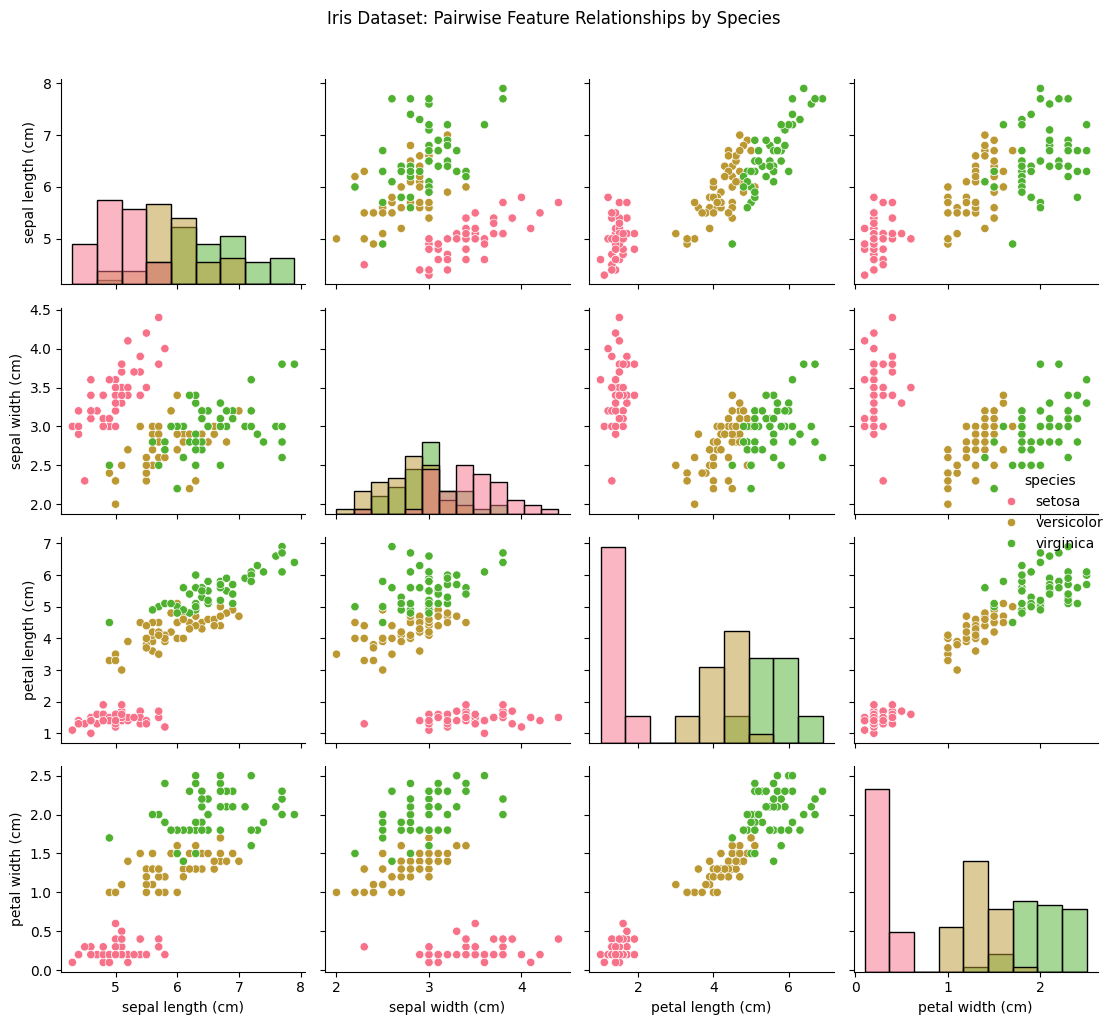

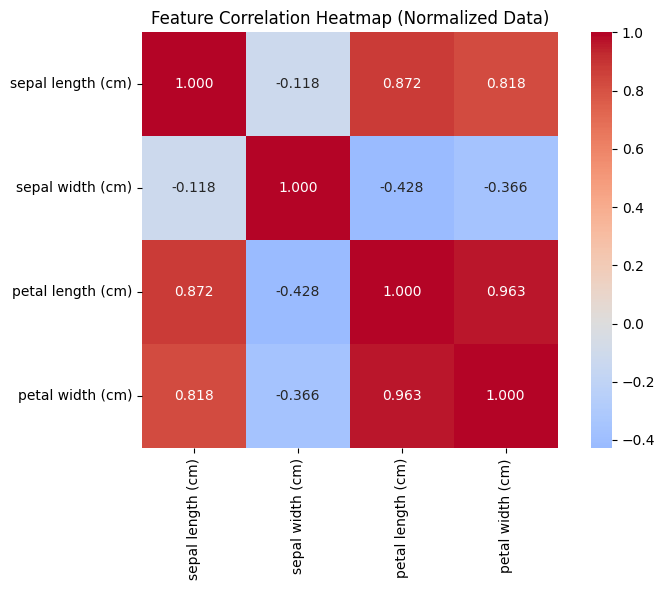

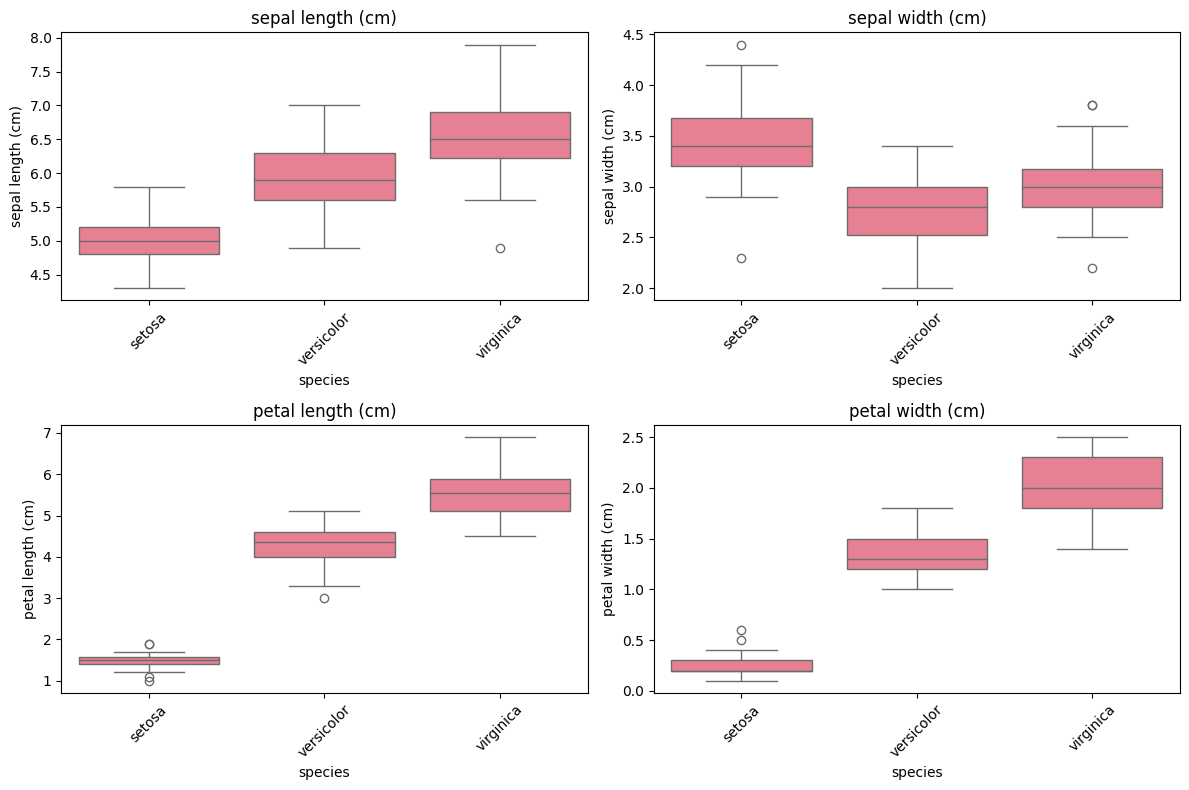

In [10]:
# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# 1. Fixed Pairplot with original (non-normalized) data for better visibility
print("Creating pairplot with original data...")
plot_df_original = df.copy()  # Use original data for better visual contrast

plt.figure(figsize=(12, 10))
pairplot = sns.pairplot(plot_df_original, hue='species', diag_kind='hist',
                        height=2.5)
pairplot.fig.suptitle('Iris Dataset: Pairwise Feature Relationships by Species', y=1.02)
plt.tight_layout()
plt.savefig('iris_pairplot_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Correlation heatmap (normalized data)
plt.figure(figsize=(8, 6))
correlation_matrix = X_normalized_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f')
plt.title('Feature Correlation Heatmap (Normalized Data)')
plt.tight_layout()
plt.savefig('iris_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Boxplots with original data for better scale visibility
plt.figure(figsize=(12, 8))
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x='species', y=feature)
    plt.title(f'{feature}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('iris_boxplots_original_scale.png', dpi=300,
bbox_inches='tight')
plt.show()


## Train-Test Split

In [ ]:
# Create train/test split function (80/20)
def create_train_test_split(X_data, y_data, test_size=0.2, random_state=42):
    """
    Create train/test split with specified proportions

    Args:
        X_data: Feature data (normalized)
        y_data: Target labels
        test_size: Proportion for test set (default 0.2 = 20%)
        random_state: Random seed for reproducibility

    Returns:
        X_train, X_test, y_train, y_test
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data,
        test_size=test_size,
        random_state=random_state,
        stratify=y_data  # Ensure balanced classes in both splits
    )
    
    # Print split information
    print(f"Training set: {len(X_train)} samples ({len(X_train)/len(X_data)*100:.1f}%)")
    print(f"Test set: {len(X_test)} samples ({len(X_test)/len(X_data)*100:.1f}%)")
    
    # Check class distribution in splits
    print(f"\nClass distribution in training set:")
    train_counts = pd.Series(y_train).value_counts().sort_index()
    for species, count in train_counts.items():
        print(f"  {species}: {count} samples")

    print(f"\nClass distribution in test set:")
    test_counts = pd.Series(y_test).value_counts().sort_index()
    for species, count in test_counts.items():
        print(f"  {species}: {count} samples")

    return X_train, X_test, y_train, y_test

# Apply the split function to our normalized data
X_train, X_test, y_train, y_test = create_train_test_split(X_normalized, y)

# Save the splits for use in subsequent mining tasks
print(f"\nData splits ready for clustering and classification tasks!")
print(f"Feature matrix shape: {X_normalized.shape}")
print(f"Training features: {X_train.shape}")
print(f"Test features: {X_test.shape}")

SyntaxError: unterminated triple-quoted string literal (detected at line 70) (1296907789.py, line 25)